In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# importing data

data = pd.read_csv('/content/drive/MyDrive/lab/data.csv')
train = data[:30000]
test = data[30000:]

X = train.drop(columns=['label'])
X = X.transpose()
Y = train['label']

X_t = test.drop(columns=['label'])
X_t = X_t.transpose()
Y_t = test['label']

In [ ]:
# initialise params
# two hidden layers with 16 neurons each

W1 = np.random.rand(16, 784) - 0.5
B1 = np.random.rand(16) - 0.5

W2 = np.random.rand(16, 16) - 0.5
B2 = np.random.rand(16) - 0.5

W3 = np.random.rand(10, 16) - 0.5
B3 = np.random.rand(10) - 0.5

In [ ]:
# one-hot encoding
m = 30000

Y_one = np.zeros((m, 10))

for i in range(m):
    Y_one[i][Y[i]] = 1

Y_one = Y_one.T

In [ ]:
import warnings
warnings.filterwarnings("ignore")

epoch = 500
alpha = 0.8
cost = np.zeros(m)

# training

for run in range(epoch):
    cost_temp = 0
    dw1 = np.zeros((16, 784))
    db1 = np.zeros(16)
    dw2 = np.zeros((16, 16))
    db2 = np.zeros(16)
    dw3 = np.zeros((10, 16))
    db3 = np.zeros(10)
    for i in range(m):
        # Forward prop
        Z1 = np.dot(W1, X[i]) + B1
        A1 = 1/(1+np.exp(-Z1+1e-5))

        Z2 = np.dot(W2, A1) + B2
        A2 = 1/(1+np.exp(-Z2+1e-5))

        Z3 = np.dot(W3, A2) + B3
        y = np.exp(Z3+1e-5)
        y /= sum(y)

        # Cost
        loss = -np.log(y[Y[i]])
        cost_temp += loss

        # Back prop
        dz3 = y - Y_one.T[i]
        dw3 += np.outer(dz3, A2)
        db3 += dz3
        da2 = np.dot(W3.T, dz3)
        dz2 = A2*(1 - A2)*da2
        dw2 += np.outer(dz2, A1)
        db2 += dz2
        da1 = np.dot(W2.T, dz2)
        dz1 = A1*(1 - A1)*da1
        dw1 += np.outer(dz1, X[i])
        db1 += dz1

        # Update params (non-vectorized, per example)
    W3 -= alpha*dw3/m
    B3 -= alpha*db3/m
    W2 -= alpha*dw2/m
    B2 -= alpha*db2/m
    W1 -= alpha*dw1/m
    B1 -= alpha*db1/m

    cost[run] = cost_temp / m

    if run % 25 == 0:
        print(f"Epoch: {run+24}/{epoch}")

Epoch: 24/500
Epoch: 49/500
Epoch: 74/500
Epoch: 99/500
Epoch: 124/500
Epoch: 149/500
Epoch: 174/500
Epoch: 199/500
Epoch: 224/500
Epoch: 249/500
Epoch: 274/500
Epoch: 299/500
Epoch: 324/500
Epoch: 349/500
Epoch: 374/500
Epoch: 399/500
Epoch: 424/500
Epoch: 449/500
Epoch: 474/500
Epoch: 499/500


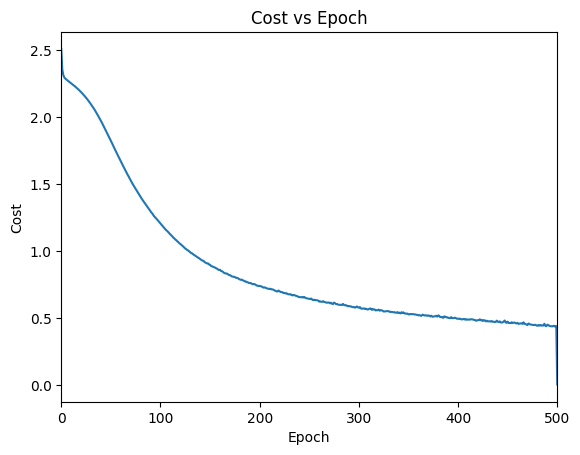

In [ ]:
import matplotlib.pyplot as plt

plt.plot(cost)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Cost vs Epoch")
plt.xlim(0, 500)
plt.show()


In [ ]:
# training accuracy
Z1 = np.dot(W1, X) + B1.reshape(-1, 1)
A1 = 1/(1+np.exp(-Z1))

Z2 = np.dot(W2, A1) + B2.reshape(-1, 1)
A2 = 1/(1+np.exp(-Z2))

Z3 = np.dot(W3, A2) + B3.reshape(-1, 1)
y = np.exp(Z3)
y /= sum(y)

predictions = np.argmax(y, axis=0)
train_accuracy = np.sum(predictions == Y) / len(Y) * 100

# test accuracy
Z1_t = np.dot(W1, X_t) + B1.reshape(-1, 1)
A1_t = 1/(1+np.exp(-Z1_t))

Z2_t = np.dot(W2, A1_t) + B2.reshape(-1, 1)
A2_t = 1/(1+np.exp(-Z2_t))

Z3_t = np.dot(W3, A2_t) + B3.reshape(-1, 1)
y_t = np.exp(Z3_t)
y_t /= sum(y_t)

predictions_t = np.argmax(y_t, axis=0)
test_accuracy = np.sum(predictions_t == Y_t) / len(Y_t) * 100

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)


Training accuracy: 87.22333333333333
Test accuracy: 85.65
